# Price vs. Actual Expense Mismatch Analysis

This notebook compares listed API prices (per-token) with actual total costs observed across all benchmark datasets.

In [224]:
import json
import os
import pandas as pd
from pathlib import Path

In [225]:
# -- Paths --
PROJECT_ROOT = Path(os.getcwd()).resolve()
if PROJECT_ROOT.name == 'analysis':
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_INFO_PATH = PROJECT_ROOT / 'constant' / 'model_info.json'
EXPERIMENT_CONFIG_PATH = PROJECT_ROOT / 'constant' / 'experiment_config.json'
DATA_DIR = PROJECT_ROOT / 'data' / 'consolidated'

# -- Load provider colours from config --
with open(EXPERIMENT_CONFIG_PATH) as _f:
    _exp_cfg = json.load(_f)
PROVIDER_COLORS = _exp_cfg.get('provider_colors', {})

In [226]:
def load_price_and_expense():
    """
    Build a DataFrame containing, for each model:
      - Listed input / output prices (per 1M tokens)
      - Actual totals across all benchmark datasets:
        total_prompt_tokens, total_completion_tokens, total_thinking_tokens,
        total_cost (as reported in data files),
        computed_cost (re-computed from listed prices and token counts),
        and the mismatch between the two.

    Returns
    -------
    pd.DataFrame
    """
    # Load configs
    with open(MODEL_INFO_PATH) as f:
        model_info = json.load(f)
    with open(EXPERIMENT_CONFIG_PATH) as f:
        exp_config = json.load(f)

    # Build a lookup: model_name -> pricing info
    price_lookup = {m['model_name']: m for m in model_info['models']}

    datasets = exp_config['datasets']
    models = exp_config['models']

    rows = []
    for model in models:
        model_name = model['model_name']
        short_name = model['short_name']
        provider = model['provider']
        pricing = price_lookup.get(model_name, {})

        input_price = pricing.get('input_price_per_MTok', None)
        output_price = pricing.get('output_price_per_MTok', None)

        total_prompt_tokens = 0
        total_completion_tokens = 0
        total_thinking_tokens = 0
        total_reported_cost = 0.0
        total_counts = 0
        datasets_found = 0

        for ds in datasets:
            file_prefix = ds['file_prefix']
            filename = f"{file_prefix}-{model_name}.json"
            filepath = DATA_DIR / filename

            if not filepath.exists():
                continue

            with open(filepath) as f:
                data = json.load(f)

            datasets_found += 1
            total_prompt_tokens += data.get('prompt_tokens', 0)
            total_completion_tokens += data.get('completion_tokens', 0)
            total_reported_cost += data.get('cost', 0.0)
            total_counts += data.get('counts', 0)

            # Sum per-record thinking tokens
            for rec in data.get('records', []):
                total_thinking_tokens += rec.get('thinking_tokens', 0)

        # Compute cost from listed prices
        if input_price is not None and output_price is not None:
            computed_cost = (
                total_prompt_tokens * input_price / 1_000_000
                + total_completion_tokens * output_price / 1_000_000
            )
        else:
            computed_cost = None

        rows.append({
            'model_name': model_name,
            'short_name': short_name,
            'provider': provider,
            'input_price_per_MTok': input_price,
            'output_price_per_MTok': output_price,
            'total_prompt_tokens': total_prompt_tokens,
            'total_completion_tokens': total_completion_tokens,
            'total_thinking_tokens': total_thinking_tokens,
            'total_non_thinking_tokens': total_completion_tokens - total_thinking_tokens,
            'total_counts': total_counts,
            'datasets_found': datasets_found,
            'reported_cost': round(total_reported_cost, 4),
            'computed_cost': round(computed_cost, 4) if computed_cost is not None else None,
            'mismatch': round(total_reported_cost - computed_cost, 4) if computed_cost is not None else None,
            'mismatch_pct': round((total_reported_cost - computed_cost) / computed_cost * 100, 2) if computed_cost else None,
        })

    df = pd.DataFrame(rows)
    return df

In [227]:
df = load_price_and_expense()
df

,model_name,short_name,provider,input_price_per_MTok,output_price_per_MTok,total_prompt_tokens,total_completion_tokens,total_thinking_tokens,total_non_thinking_tokens,total_counts,datasets_found,reported_cost,computed_cost,mismatch,mismatch_pct
0,gpt-5.2-high,GPT-5.2,OpenAI,1.75,14.0,3639767,37158800,34067711,3091089,11872,9,526.5928,526.5928,-0.0,-0.0
1,gpt-5-mini,GPT-5 Mini,OpenAI,0.25,2.0,3751688,26000195,23151246,2848949,12068,9,52.9383,52.9383,0.0,0.0
2,gemini-3.1-pro-preview,Gemini 3.1 Pro,Google,2.00,12.0,3850819,96754148,91876957,4877191,12068,9,1168.7514,1168.7514,-0.0,-0.0
3,gemini-3-flash-preview,Gemini 3 Flash,Google,0.50,3.0,3850819,213679605,208679772,4999833,12068,9,642.9642,642.9642,0.0,0.0
4,claude-opus-4.6-thinking,Claude Opus 4.6,Anthropic,5.00,25.0,4286153,29855612,24197362,5658250,11890,9,767.8211,767.8211,0.0,0.0
5,claude-haiku-4.5,Claude Haiku 4.5,Anthropic,1.00,5.0,4076953,6527103,24308,6502795,12068,9,36.7125,36.7125,0.0,0.0
6,kimi-k2.5,Kimi K2.5,Moonshot AI,0.60,3.0,3753119,95920854,91596524,4324330,12068,9,290.0144,290.0144,0.0,0.0
7,MiniMax-M2.5,MiniMax-M2.5,MiniMax,0.30,1.2,4090049,18106681,17229313,877368,12068,9,22.9550,22.9550,-0.0,-0.0


In [228]:
# Display key columns in a cleaner view
summary_cols = [
    'short_name', 'provider',
    'input_price_per_MTok', 'output_price_per_MTok',
    'total_prompt_tokens', 'total_completion_tokens', 'total_thinking_tokens',
    'reported_cost', 'computed_cost', 'mismatch', 'mismatch_pct'
]
df[summary_cols].style.format({
    'input_price_per_MTok': '${:.2f}',
    'output_price_per_MTok': '${:.2f}',
    'total_prompt_tokens': '{:,.0f}',
    'total_completion_tokens': '{:,.0f}',
    'total_thinking_tokens': '{:,.0f}',
    'reported_cost': '${:.4f}',
    'computed_cost': '${:.4f}',
    'mismatch': '${:.4f}',
    'mismatch_pct': '{:.2f}%',
}).set_caption('Price vs Actual Expense Comparison')

,short_name,provider,input_price_per_MTok,output_price_per_MTok,total_prompt_tokens,total_completion_tokens,total_thinking_tokens,reported_cost,computed_cost,mismatch,mismatch_pct
0,GPT-5.2,OpenAI,$1.75,$14.00,"3,639,767","37,158,800","34,067,711",$526.5928,$526.5928,$-0.0000,-0.00%
1,GPT-5 Mini,OpenAI,$0.25,$2.00,"3,751,688","26,000,195","23,151,246",$52.9383,$52.9383,$0.0000,0.00%
2,Gemini 3.1 Pro,Google,$2.00,$12.00,"3,850,819","96,754,148","91,876,957",$1168.7514,$1168.7514,$-0.0000,-0.00%
3,Gemini 3 Flash,Google,$0.50,$3.00,"3,850,819","213,679,605","208,679,772",$642.9642,$642.9642,$0.0000,0.00%
4,Claude Opus 4.6,Anthropic,$5.00,$25.00,"4,286,153","29,855,612","24,197,362",$767.8211,$767.8211,$0.0000,0.00%
5,Claude Haiku 4.5,Anthropic,$1.00,$5.00,"4,076,953","6,527,103","24,308",$36.7125,$36.7125,$0.0000,0.00%
6,Kimi K2.5,Moonshot AI,$0.60,$3.00,"3,753,119","95,920,854","91,596,524",$290.0144,$290.0144,$0.0000,0.00%
7,MiniMax-M2.5,MiniMax,$0.30,$1.20,"4,090,049","18,106,681","17,229,313",$22.9550,$22.9550,$-0.0000,-0.00%


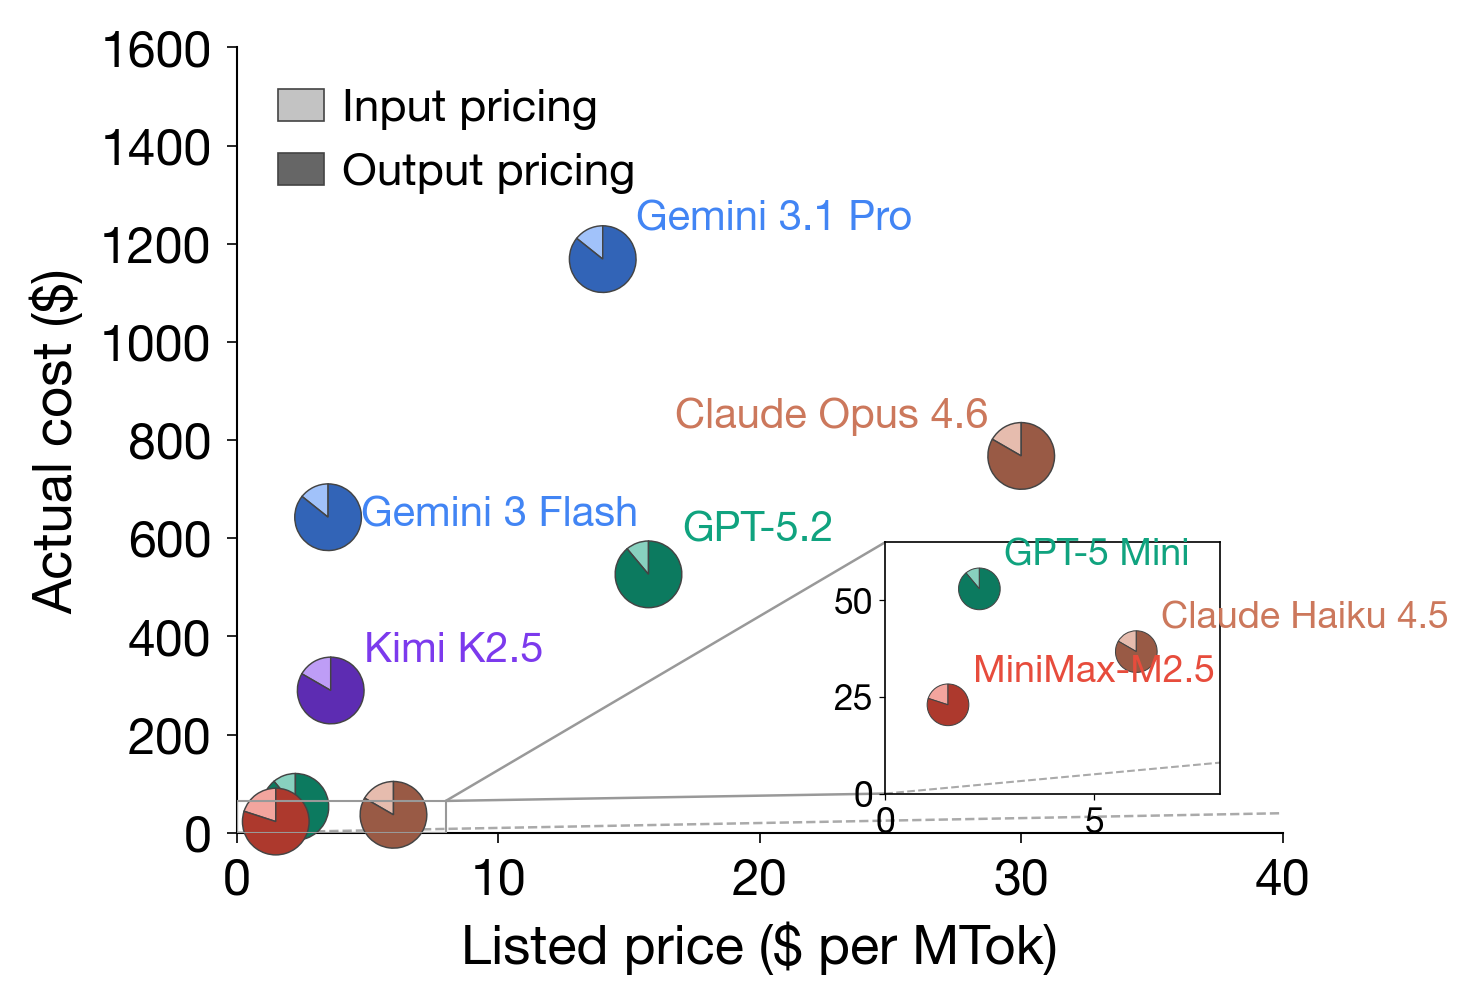

In [229]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch
from matplotlib.transforms import ScaledTranslation
from matplotlib.offsetbox import AnnotationBbox, DrawingArea

# ── Nature-style defaults (shared by all figure cells) ───────────────
NATURE_RC = {
    'font.family':        'Helvetica Neue',
    'font.size':          13,
    'axes.titlesize':     14,
    'axes.labelsize':     13,
    'xtick.labelsize':    12,
    'ytick.labelsize':    12,
    'legend.fontsize':    12,
    'figure.dpi':         300,
    'savefig.dpi':        300,
    'axes.linewidth':     0.5,
    'xtick.major.width':  0.4,
    'ytick.major.width':  0.4,
    'xtick.major.size':   2.5,
    'ytick.major.size':   2.5,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
}
plt.rcParams.update(NATURE_RC)

FIG_H = 3.4

# ── Reload provider colours (brand-aligned palette) ─────────────────
import json as _json
with open(EXPERIMENT_CONFIG_PATH) as _f:
    PROVIDER_COLORS = _json.load(_f).get('provider_colors', {})

# ── Helper: light / dark variant of a colour ────────────────────────
def color_light(hex_color, factor=0.50):
    r, g, b = mcolors.to_rgb(hex_color)
    return (r + (1 - r) * factor, g + (1 - g) * factor, b + (1 - b) * factor)

def color_dark(hex_color, factor=0.25):
    r, g, b = mcolors.to_rgb(hex_color)
    return (r * (1 - factor), g * (1 - factor), b * (1 - factor))

# ── Compute derived columns ─────────────────────────────────────────
df['listed_blended'] = df['input_price_per_MTok'] + df['output_price_per_MTok']
df_sorted = df.sort_values('listed_blended', ascending=False).reset_index(drop=True)


# =====================================================================
# draw_panel_a  –  Scatter: Listed price vs Actual cost
# =====================================================================
# Label configs: (ha, va, dx_pts, dy_pts) — offsets in *points*
LABEL_MAIN = {
    'GPT-5.2':           ('left',  'bottom',  8,  6),
    'Gemini 3.1 Pro':    ('left',  'bottom',  8,  5),
    'Gemini 3 Flash':    ('left',  'top',     8,  5),
    'Claude Opus 4.6':   ('right', 'bottom', -8,  5),
    'Kimi K2.5':         ('left',  'bottom',  8,  5),
}
LABEL_INSET = {
    'GPT-5 Mini':       ('left',  'bottom',  6,  4),
    'Claude Haiku 4.5': ('left',  'bottom',  6,  4),
    'MiniMax-M2.5':     ('left',  'bottom',  6,  4),
}


def draw_panel_a(ax, df_sorted):
    """Draw panel (a): scatter plot with pie-chart markers + inset zoom."""
    # Round axis limits up to clean multiples so ticks are unambiguous
    x_raw = df_sorted['listed_blended'].max() * 1.25
    y_raw = df_sorted['reported_cost'].max() * 1.35
    x_step = 10
    y_step = 200
    x_max = int(np.ceil(x_raw / x_step)) * x_step
    y_max = int(np.ceil(y_raw / y_step)) * y_step

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    ax.set_xticks(np.arange(0, x_max + 1, x_step))
    ax.set_yticks(np.arange(0, y_max + 1, y_step))
    ax.set_facecolor('none')
    ax.set_xlabel('Listed price ($ per MTok)')
    ax.set_ylabel('Actual cost ($)')

    diag_end = min(x_max, y_max)
    ax.plot([0, diag_end], [0, diag_end], ls='--', lw=0.6, color='#AAAAAA', zorder=0)

    # ── Pie-chart scatter (display-space circles) ───────────────────
    PIE_R = 8  # radius in points — always circular
    for _, row in df_sorted.iterrows():
        x_val = row['listed_blended']
        y_val = row['reported_cost']
        color = PROVIDER_COLORS.get(row['provider'], '#888888')
        ratio_in = row['input_price_per_MTok'] / (row['input_price_per_MTok'] + row['output_price_per_MTok'])
        theta = ratio_in * 360
        da = DrawingArea(2 * PIE_R, 2 * PIE_R, PIE_R, PIE_R)
        da.add_artist(mpatches.Wedge(
            (0, 0), PIE_R, 90, 90 + theta,
            fc=color_light(color), ec='#444', lw=0.35))
        da.add_artist(mpatches.Wedge(
            (0, 0), PIE_R, 90 + theta, 450,
            fc=color_dark(color), ec='#444', lw=0.35))
        ab = AnnotationBbox(da, (x_val, y_val), frameon=False,
                            pad=0, zorder=3)
        ax.add_artist(ab)

    # ── Main-view labels (offset in points) ─────────────────────────
    for _, row in df_sorted.iterrows():
        name = row['short_name']
        if name not in LABEL_MAIN:
            continue
        ha, va, dx, dy = LABEL_MAIN[name]
        ax.annotate(name, (row['listed_blended'], row['reported_cost']),
                    xytext=(dx, dy), textcoords='offset points',
                    fontsize=10, ha=ha, va=va,
                    color=PROVIDER_COLORS.get(row['provider'], '#555'))

    # ── Inset zoom ──────────────────────────────────────────────────
    zoom_x = (0, 8)
    zoom_y = (0, 65)
    ax_in = ax.inset_axes([0.62, 0.05, 0.32, 0.32])
    ax_in.set_facecolor('white')
    ax_in.patch.set_alpha(1.0)
    ax_in.set_xlim(*zoom_x)
    ax_in.set_ylim(*zoom_y)
    ax_in.tick_params(labelsize=8.5, length=1.5, width=0.3, pad=1.5)
    for sp in ('top', 'right', 'bottom', 'left'):
        ax_in.spines[sp].set_visible(True)
        ax_in.spines[sp].set_linewidth(0.4)

    diag_end_in = min(zoom_x[1], zoom_y[1])
    ax_in.plot([0, diag_end_in], [0, diag_end_in],
               ls='--', lw=0.5, color='#AAAAAA', zorder=0)

    INSET_PIE_R = 5
    mask = (df_sorted['listed_blended'] <= zoom_x[1]) & \
           (df_sorted['reported_cost'] <= zoom_y[1])
    for _, row in df_sorted[mask].iterrows():
        x_val = row['listed_blended']
        y_val = row['reported_cost']
        color = PROVIDER_COLORS.get(row['provider'], '#888888')
        ratio_in = row['input_price_per_MTok'] / (row['input_price_per_MTok'] + row['output_price_per_MTok'])
        theta = ratio_in * 360
        da = DrawingArea(2 * INSET_PIE_R, 2 * INSET_PIE_R,
                         INSET_PIE_R, INSET_PIE_R)
        da.add_artist(mpatches.Wedge(
            (0, 0), INSET_PIE_R, 90, 90 + theta,
            fc=color_light(color), ec='#444', lw=0.25))
        da.add_artist(mpatches.Wedge(
            (0, 0), INSET_PIE_R, 90 + theta, 450,
            fc=color_dark(color), ec='#444', lw=0.25))
        ab = AnnotationBbox(da, (x_val, y_val), frameon=False,
                            pad=0, zorder=3)
        ax_in.add_artist(ab)

    for _, row in df_sorted[mask].iterrows():
        name = row['short_name']
        if name not in LABEL_INSET:
            continue
        ha, va, dx, dy = LABEL_INSET[name]
        ax_in.annotate(name, (row['listed_blended'], row['reported_cost']),
                       xytext=(dx, dy), textcoords='offset points',
                       fontsize=9, ha=ha, va=va,
                       color=PROVIDER_COLORS.get(row['provider'], '#555'))

    # ── Zoom rectangle on main axes ─────────────────────────────────
    rect = mpatches.Rectangle((zoom_x[0], zoom_y[0]),
                               zoom_x[1] - zoom_x[0], zoom_y[1] - zoom_y[0],
                               lw=0.5, ec='#999999', fc='none', zorder=5)
    ax.add_patch(rect)

    # ── Connector lines: fan from rect top-right → inset corners ────
    rect_tr = (zoom_x[1], zoom_y[1])
    fan_targets_ax_frac = [(0.62, 0.37), (0.62, 0.05)]
    for (frac_x, frac_y) in fan_targets_ax_frac:
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        target_data_x = xlim[0] + frac_x * (xlim[1] - xlim[0])
        target_data_y = ylim[0] + frac_y * (ylim[1] - ylim[0])
        con = ConnectionPatch(
            xyA=rect_tr, coordsA='data',
            xyB=(target_data_x, target_data_y), coordsB='data',
            axesA=ax, axesB=ax,
            color='#999999', lw=0.6, zorder=4
        )
        ax.add_artist(con)

    # ── Legend ──────────────────────────────────────────────────────
    _grey = '#888888'
    legend_elements = [
        mpatches.Patch(fc=color_light(_grey), ec='#444', lw=0.4,
                       label='Input pricing'),
        mpatches.Patch(fc=color_dark(_grey),  ec='#444', lw=0.4,
                       label='Output pricing'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', frameon=False,
              fontsize=11, handlelength=1.0, handletextpad=0.4)

# ── Standalone figure ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, FIG_H))
draw_panel_a(ax, df_sorted)

fig.patch.set_alpha(0)
plt.show()

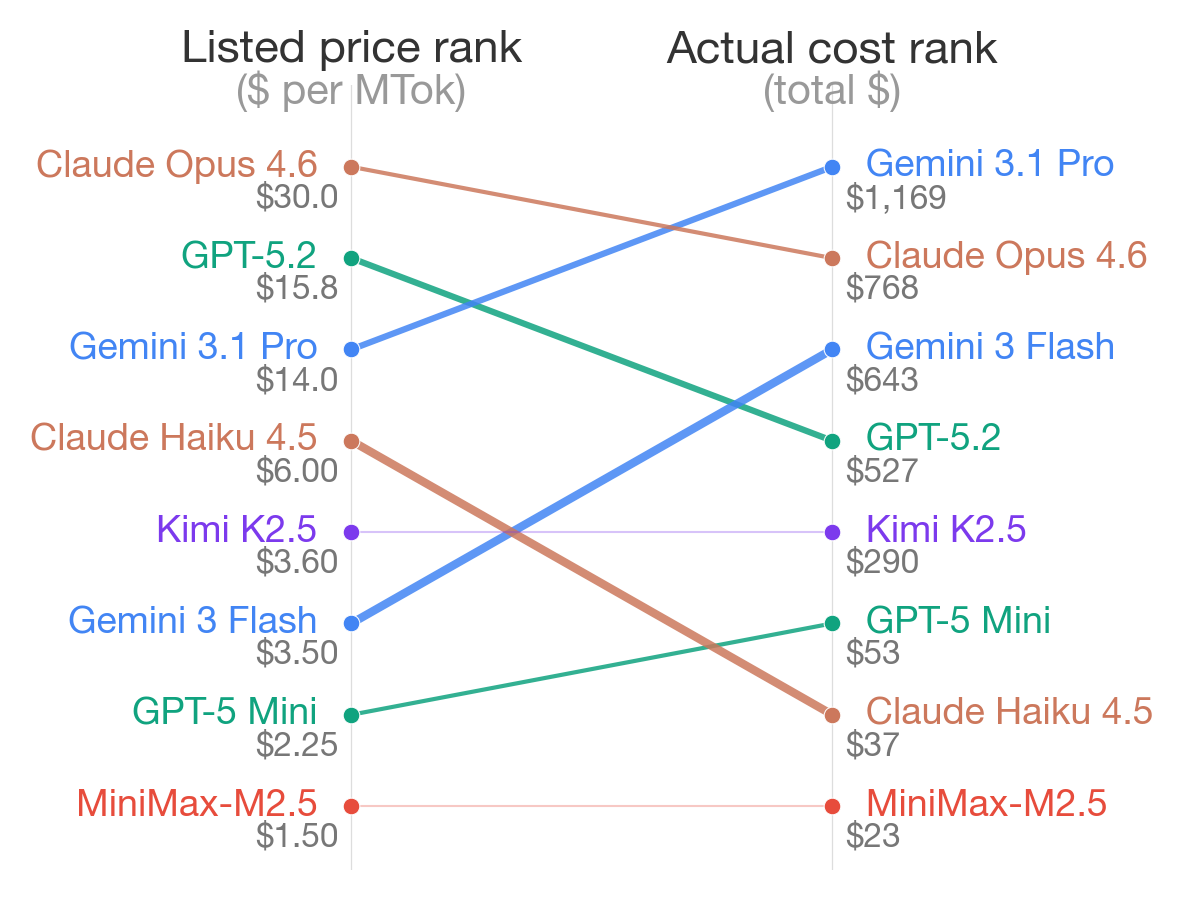

In [230]:
# =====================================================================
# draw_panel_b  –  slope chart: Listed price rank → Actual cost rank
# =====================================================================
def draw_panel_b(ax, df):
    """Draw panel (b): slope chart showing ranking inversions."""
    df = df.copy()
    df['price_rank'] = df['listed_blended'].rank(method='min', ascending=False).astype(int)
    df['cost_rank']  = df['reported_cost'].rank(method='min', ascending=False).astype(int)
    n = len(df)

    x_left, x_right = 0, 1.5
    ax.set_xlim(-0.70, 2.20)
    ax.set_ylim(0.1, n + 0.7)
    ax.invert_yaxis()

    # ── Line width mapping ──────────────────────────────────────────
    def rank_change_lw(delta):
        return 0.5 if delta == 0 else 0.5 + delta * 0.5

    # ── Slope lines ─────────────────────────────────────────────────
    for _, row in df.iterrows():
        pr = row['price_rank']
        cr = row['cost_rank']
        color = PROVIDER_COLORS.get(row['provider'], '#888888')
        delta = abs(pr - cr)
        lw    = rank_change_lw(delta)
        alpha = 0.85 if delta > 0 else 0.30
        ax.plot([x_left, x_right], [pr, cr],
                color=color, lw=lw, alpha=alpha, zorder=2)

    # ── Dots + labels ───────────────────────────────────────────────
    for _, row in df.iterrows():
        pr    = row['price_rank']
        cr    = row['cost_rank']
        name  = row['short_name']
        color = PROVIDER_COLORS.get(row['provider'], '#888888')
        blended = row['listed_blended']
        cost    = row['reported_cost']

        # Left column
        ax.scatter(x_left, pr, s=16, color=color, zorder=4,
                   edgecolors='white', linewidths=0.25)
        price_str = f"${blended:.2f}" if blended < 10 else f"${blended:.1f}"
        ax.text(x_left - 0.04, pr, f"{name}  ",
                ha='right', va='center', fontsize=9, fontweight='medium',
                color=color)
        ax.text(x_left - 0.04, pr + 0.35, price_str,
                ha='right', va='center', fontsize=8, color='#777777')

        # Right column
        ax.scatter(x_right, cr, s=16, color=color, zorder=4,
                   edgecolors='white', linewidths=0.25)
        cost_str = f"${cost:,.0f}"
        ax.text(x_right + 0.04, cr, f"  {name}",
                ha='left', va='center', fontsize=9, fontweight='medium',
                color=color)
        ax.text(x_right + 0.04, cr + 0.35, cost_str,
                ha='left', va='center', fontsize=8, color='#777777')

    # ── Column headers ──────────────────────────────────────────────
    ax.text(x_left, -0.05, 'Listed price rank', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#333333')
    ax.text(x_right, -0.05, 'Actual cost rank', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#333333')
    ax.text(x_left, -0.05 + 0.45, '($ per MTok)', ha='center', va='bottom',
            fontsize=10, color='#999999')
    ax.text(x_right, -0.05 + 0.45, '(total $)', ha='center', va='bottom',
            fontsize=10, color='#999999')

    # ── Clean up ────────────────────────────────────────────────────
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.axvline(x_left,  color='#DDDDDD', lw=0.3, zorder=0)
    ax.axvline(x_right, color='#DDDDDD', lw=0.3, zorder=0)

# ── Standalone figure ────────────────────────────────────────────────
plt.rcParams.update(NATURE_RC)
fig, ax = plt.subplots(figsize=(4.0, FIG_H))
draw_panel_b(ax, df)

fig.patch.set_alpha(0)
plt.show()

In [231]:
# Quick diagnostic: check actual data values
print(df_sorted[['short_name', 'listed_blended', 'computed_cost', 'reported_cost', 'mismatch_pct']].to_string())
print()
print(f"listed_blended range: {df_sorted['listed_blended'].min():.2f} – {df_sorted['listed_blended'].max():.2f}")
print(f"computed_cost range:  {df_sorted['computed_cost'].min():.4f} – {df_sorted['computed_cost'].max():.4f}")
print(f"reported_cost range:  {df_sorted['reported_cost'].min():.4f} – {df_sorted['reported_cost'].max():.4f}")

         short_name  listed_blended  computed_cost  reported_cost  mismatch_pct
0   Claude Opus 4.6           30.00       767.8211       767.8211           0.0
1           GPT-5.2           15.75       526.5928       526.5928          -0.0
2    Gemini 3.1 Pro           14.00      1168.7514      1168.7514          -0.0
3  Claude Haiku 4.5            6.00        36.7125        36.7125           0.0
4         Kimi K2.5            3.60       290.0144       290.0144           0.0
5    Gemini 3 Flash            3.50       642.9642       642.9642           0.0
6        GPT-5 Mini            2.25        52.9383        52.9383           0.0
7      MiniMax-M2.5            1.50        22.9550        22.9550          -0.0

listed_blended range: 1.50 – 30.00
computed_cost range:  22.9550 – 1168.7514
reported_cost range:  22.9550 – 1168.7514


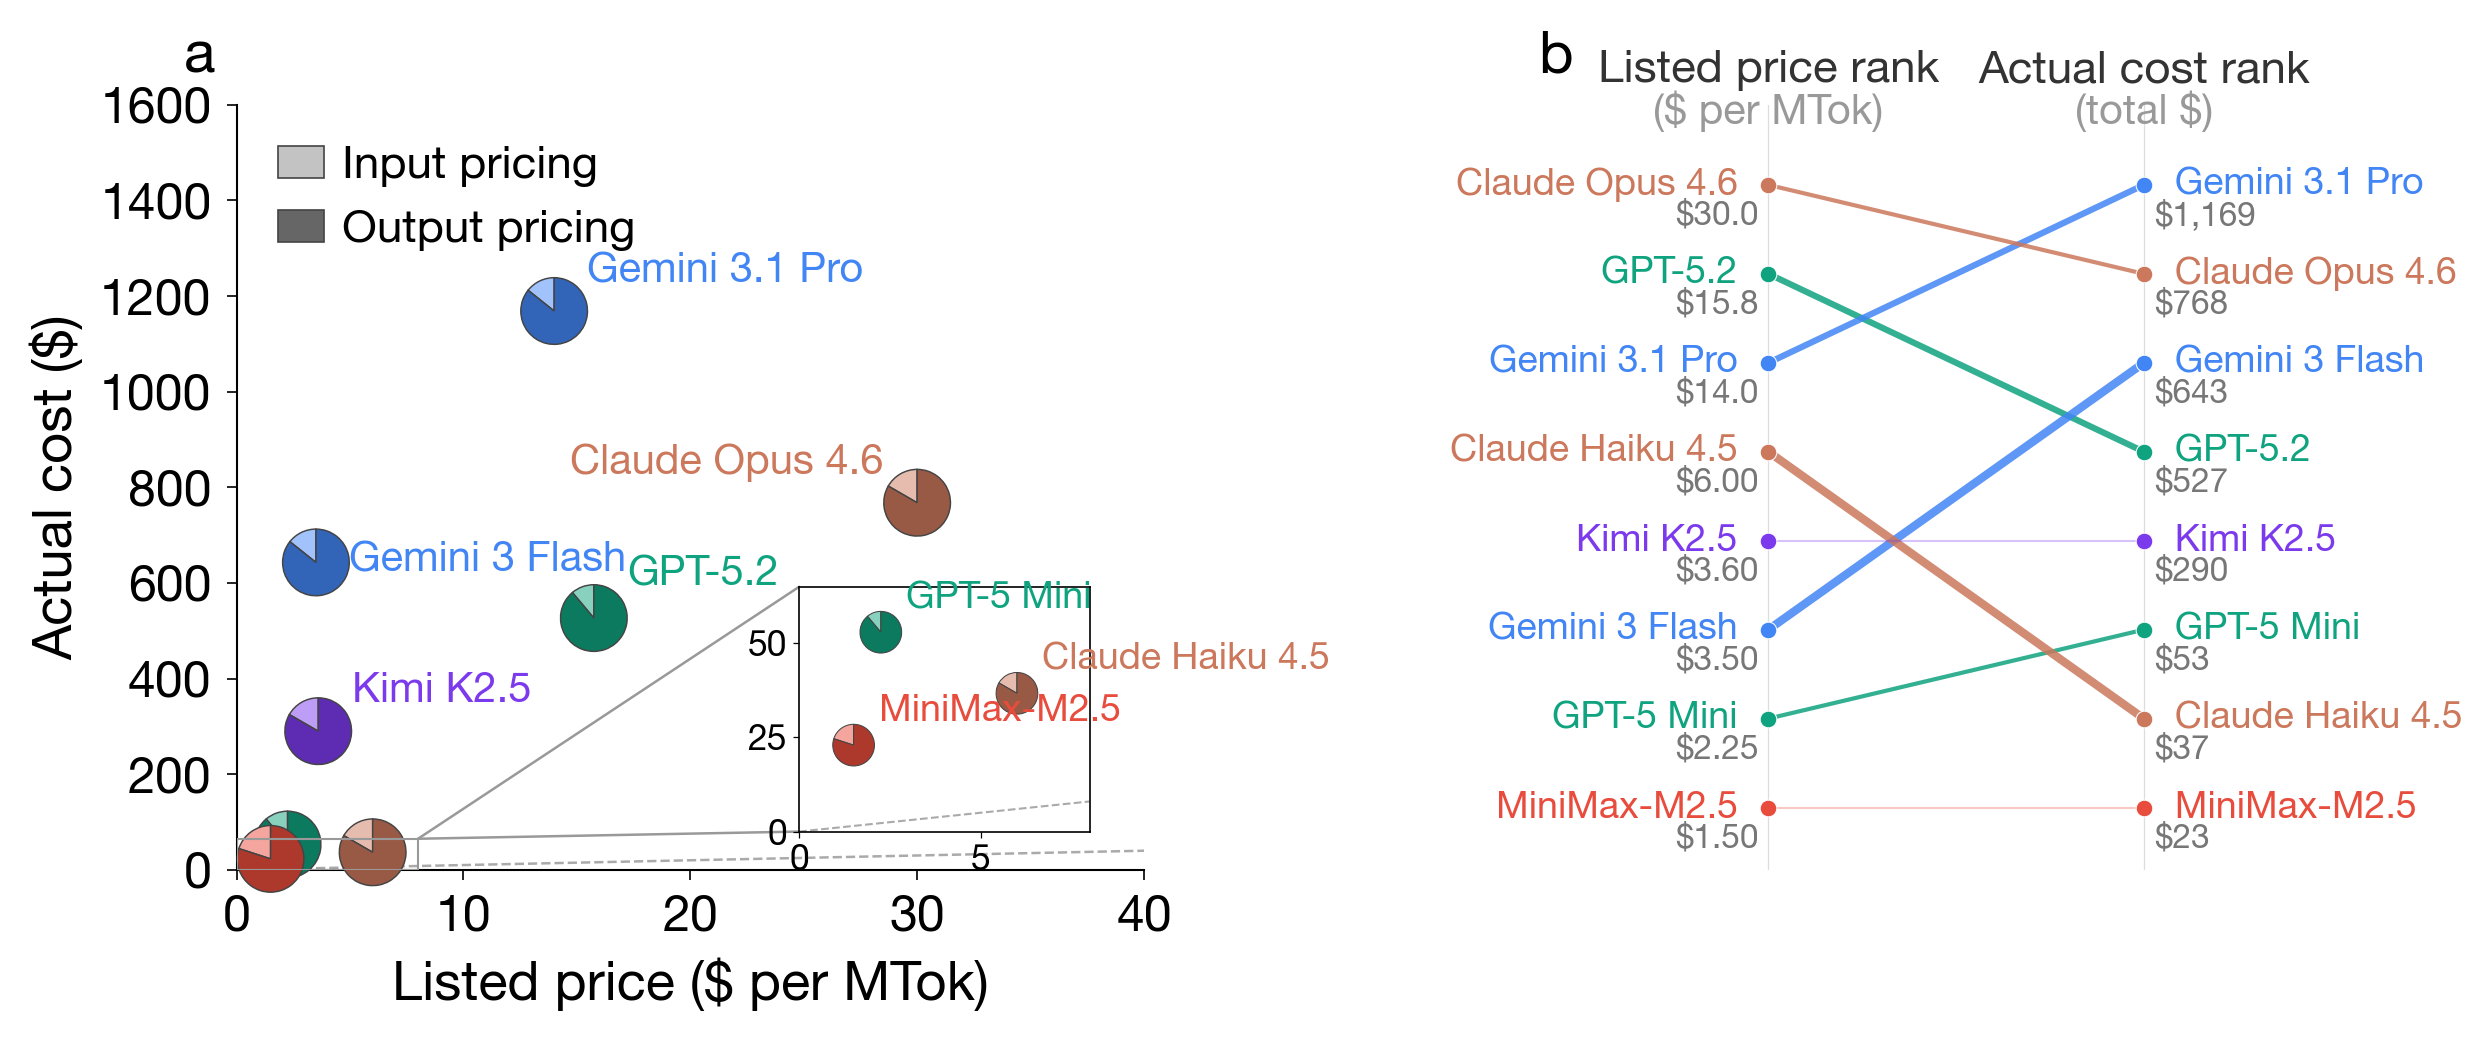


Saved to figure/figure1_combined.{pdf,png}


In [232]:
# ── Combined Figure: Panel (a) + Panel (b) side by side ──────────────
plt.rcParams.update(NATURE_RC)

fig = plt.figure(figsize=(7.8, FIG_H))
gs = gridspec.GridSpec(1, 2, width_ratios=[4.0, 3.2], wspace=0.55,
                       left=0.08, right=0.97, top=0.90, bottom=0.15)

# Panel (a)
ax_a = fig.add_subplot(gs[0])
draw_panel_a(ax_a, df_sorted)
ax_a.text(0.0, 1.0, 'a',
          transform=ax_a.transAxes + ScaledTranslation(-5/72, 5/72, fig.dpi_scale_trans),
          fontsize=14, fontweight='heavy', va='bottom', ha='right')

# Panel (b)
ax_b = fig.add_subplot(gs[1])
draw_panel_b(ax_b, df)
ax_b.text(0.0, 1.0, 'b',
          transform=ax_b.transAxes + ScaledTranslation(-5/72, 5/72, fig.dpi_scale_trans),
          fontsize=14, fontweight='heavy', va='bottom', ha='right')

fig.patch.set_alpha(0)
fig.savefig(PROJECT_ROOT / 'figure' / 'figure1_combined.pdf',
            bbox_inches='tight', pad_inches=0.01, facecolor='none')
fig.savefig(PROJECT_ROOT / 'figure' / 'figure1_combined.png',
            bbox_inches='tight', pad_inches=0.01, facecolor='none')
plt.show()
print('\nSaved to figure/figure1_combined.{pdf,png}')